In [1]:
!hostnamectl

 Static hostname: gpue02.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: 03b8ad4d5da846abbb331a11f6309515
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: CUXD670_5.32_v2.06


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [2]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [4]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [5]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [30]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_female.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [31]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 4039 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'age_sex', 'intervals_old'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

# MuSC to type1/2 transitions

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['MuSC', 'Type II', 'Type I', 'Specialized MF'])].copy()

In [ ]:
rna_adata.obs['age_sex'] = (
    rna_adata.obs['age'].astype('float').astype(int).astype(str)
    + '_' + 
    rna_adata.obs['Sex'].astype(str)
)
rna_adata.obs['age_sex'].value_counts().sort_index()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '15_Male': 'interval_1_M',
    '18_Male': 'interval_1_M',
    '34_Male': 'interval_2_M',
    '38_Male': 'interval_2_M',
    '45_Male': 'interval_2_M',
    # Female intervals
    '17_Female': 'interval_1_F',
    '29_Female': 'interval_1_F',
    '34_Female': 'interval_2_F',
}

rna_adata.obs['intervals_young'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

# Verify
rna_adata.obs['intervals_young'].value_counts()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '77_Male': 'interval_1_M',
    '79_Male': 'interval_1_M',
    '82_Male': 'interval_1_M',
    '84_Male': 'interval_1_M',
    '85_Male': 'interval_2_M',
    '88_Male': 'interval_2_M',
    # Female intervals
    '79_Female': 'interval_1_F',
    '80_Female': 'interval_1_F',
    '82_Female': 'interval_1_F',
    '84_Female': 'interval_2_F',
    '89_Female': 'interval_2_F',
    '92_Female': 'interval_2_F',
    '99_Female': 'interval_2_F'
}

rna_adata.obs['intervals_old'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

rna_adata.obs['intervals_old'].value_counts()

In [ ]:
mask = (
    # interval_1: MuSC only
    (rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_1_F']) & 
     (rna_adata.obs['Annotation'] == 'MuSC'))
    |
    # interval_2: Type II, Type I, Specialized MF only (no MuSC)
    (rna_adata.obs['intervals_old'].isin(['interval_2_M', 'interval_2_F']) & 
     rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'Specialized MF']))
)

rna_adata = rna_adata[mask].copy()

# Verify — should show no MuSC in interval_2 and no other types in interval_1
rna_adata.obs.groupby(['intervals_old', 'Annotation']).size()

In [ ]:
n_cells_downsample = 2000
adatas = []

for interval, idx in rna_adata.obs.groupby('intervals_old').groups.items():
    subset = rna_adata[idx].copy()
    
    if interval.startswith('interval_2') and subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

print(rna_adata.obs['intervals_old'].value_counts())

In [ ]:
# subset adata to male and female cells based on intervals_young
rna_adata_male = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_2_M'])].copy()
rna_adata_female = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_F', 'interval_2_F'])].copy()

In [ ]:
rna_adata_female.obs

In [ ]:

import anndata as ad
ad.settings.allow_write_nullable_strings = True
# save
rna_adata_male.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_male.h5ad')
rna_adata_female.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_female.h5ad')

#### subset to young and old transitions (separately)

In [ ]:
#young_adata = rna_adata[rna_adata.obs['sample'] == 'YM3'].copy()
#old_adata = rna_adata[rna_adata.obs['sample'] == 'YM2'].copy()


In [ ]:
# subset to samples of interest
#rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

In [ ]:
adata = rna_adata_female

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'MuSC', 'Specialized MF'])].copy()
#rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II'])].copy()

#### Lower bound on number of cells per age

In [ ]:
# age_counts = rna_adata.obs['age'].value_counts()
# valid_ages = age_counts[age_counts >= 500].index

# rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # # Verify
# print(rna_adata.obs['age'].value_counts())

#### Upper bound on number of cells per age

In [ ]:
# n_cells_downsample = 5000
# adatas = []

# for age, idx in rna_adata.obs.groupby('age').groups.items():
#     subset = rna_adata[idx].copy()
#     if subset.shape[0] > n_cells_downsample:
#         sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
#     adatas.append(subset)

# rna_adata = ad.concat(adatas)
# del adatas

# # Verify
# print(rna_adata.obs['age'].value_counts())

In [ ]:
rna_adata.obs

In [ ]:
# #load adata with sub cluster labels
# type2_sub_cluster = sc.read_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad')
# type2_sub_cluster

In [ ]:
# type2_sub_cluster.obs['Annotation'].value_counts()

In [ ]:
# subset_adata = type2_sub_cluster[type2_sub_cluster.obs['Annotation'].isin(['Type II', 'ENOX1+ (II)', 'ID1+ (II)', 'SAA2+ (II)', 'DCLK1+ (II)', 'TNNT2+ (II)'])]

In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

In [ ]:
display(rna_adata.obs['Annotation'].value_counts())
print(rna_adata.obs["Annotation"].unique())

## Instantiate OT

In [32]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_old
TCTTGGAGAC_CTGATACTTC_2_2_2,OM2_Nor4,4539.000000,2061,OM2,5.926416,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,interval_1_F
TATCGCGCCAGGCTATATAA.1_1_2_2,OM2_Nor2,2820.000000,1543,OM2,4.219858,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,interval_1_F
GGTGCGCGTACACTCAGTCA.1_1_1_2_2,OM2_Dam3,7118.000000,3149,OM2,4.636134,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,interval_1_F
AGATTAAGGA_CACATGTTAC_1_2_2,OM2_Nor3,8254.000000,3133,OM2,8.250545,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,interval_1_F
TCTTCCACAG_GTTAAGGTGA_2_2_2,OM2_Nor4,9751.000000,3543,OM2,4.707210,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,interval_1_F
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL33_N2_1_2_1_1_1_9_1,P21_5,4513.867288,1284,P21,0.016138,89.0,snRNA,Female,Spain,old_pop,Type I,89_Female,interval_2_F
CELL1145_N1_1_2_1_1_1_9_1,P21_5,1697.597709,558,P21,0.389621,89.0,snRNA,Female,Spain,old_pop,Type II,89_Female,interval_2_F
CELL1363_N1_1_1_2_9_1,P3_3,1851.412255,959,P3,0.743662,92.0,snRNA,Female,Spain,old_pop,Type II,92_Female,interval_2_F
CELL621_N1_1_2_9_1,P3_5,3691.131037,1709,P3,0.054786,92.0,snRNA,Female,Spain,old_pop,Type I,92_Female,interval_2_F


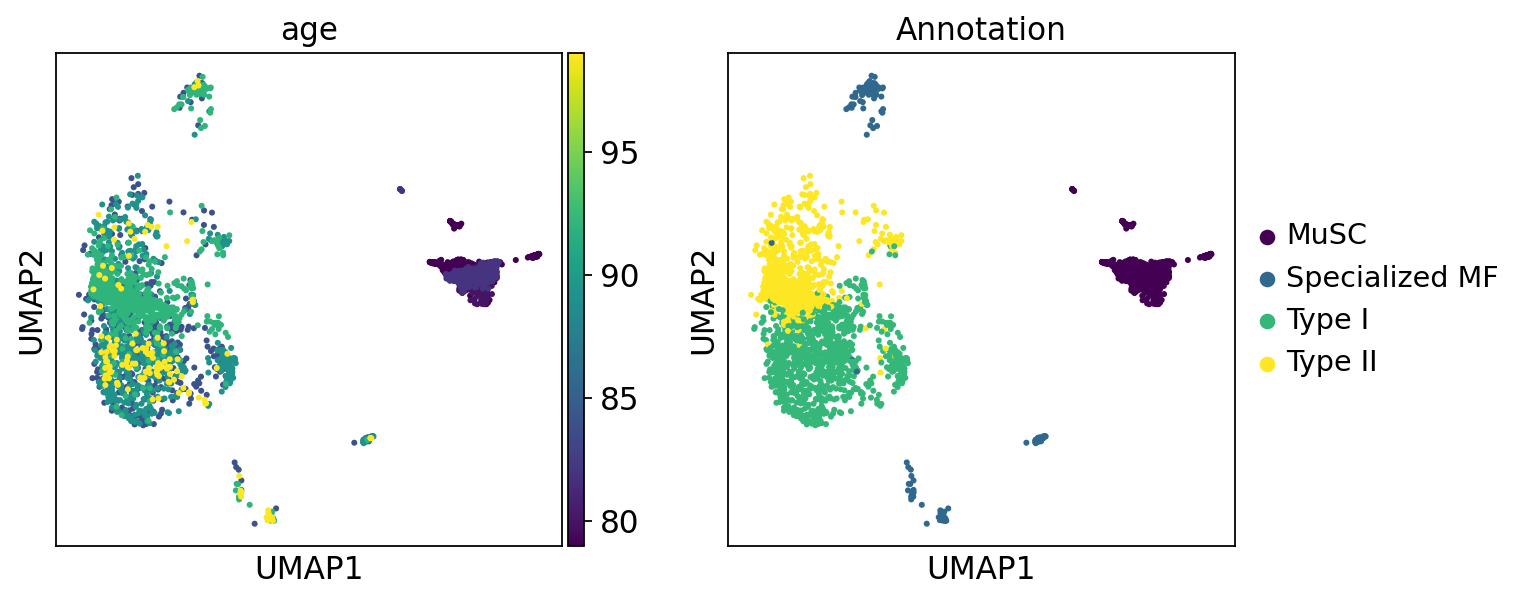

In [52]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [33]:
# make temporal info numeric
def adapt_time(x):
    if x["intervals_old"] in ["interval_1_F"]:
        return 1.5
    if x["intervals_old"] in ["interval_2_F"]:
        return 3.5
    raise ValueError
    
rna_adata.obs["intervals_old"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [34]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="intervals_old")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
computing PCA
    with n_comps=30
    finished (0:00:02)


In [35]:
import networkx as nx

batch_column = "intervals_old"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [36]:
#if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
n_components = nx.number_connected_components(G)
print(f"Number of connected components: {n_components}")
# Check sizes of each component
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Component sizes: {sizes}")

Number of connected components: 1
Component sizes: [4039]


In [37]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [38]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [39]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(2039, 2000)].                                  


W0316 04:39:30.786208  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:47.320287  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:48.443255  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:50.157686  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:50.627703  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:52.285060  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:56.115942  163612 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:39:56.119622  163613 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

### Save objects after computation

In [40]:
import cloudpickle
with open(f'{tmp_dir}/musc_transition_old_female.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [41]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_musc_transition_old_female.npz"), T_15_35_csr)

W0316 04:40:45.756250  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:40:45.782129  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:40:45.894539  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:40:45.961890  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:40:46.000228  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:40:46.039607  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:40:46.080830  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


## Visualize cell clusters of interest

In [42]:
rna_adata.obs["Annotation"] = rna_adata.obs["Annotation"].astype("category")
order_cell_types = rna_adata.obs["Annotation"].cat.categories.tolist()
order_cell_types

['MuSC', 'Specialized MF', 'Type I', 'Type II']

W0316 04:41:02.353495  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.404461  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.471657  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.510161  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.549352  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.594826  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.659342  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:02.679943  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

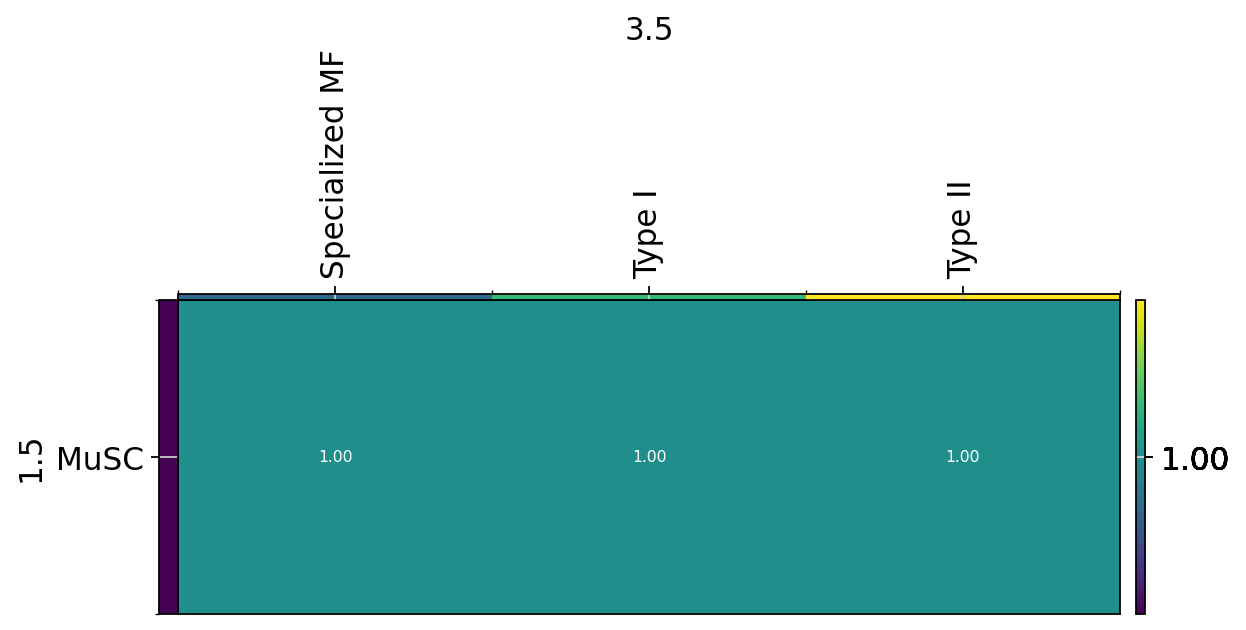

In [43]:
#aggregating the transport matrix by bins of interest
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

W0316 04:41:11.368246  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:11.395334  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:11.447546  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:11.491166  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:11.571725  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:11.616823  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:41:11.657591  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


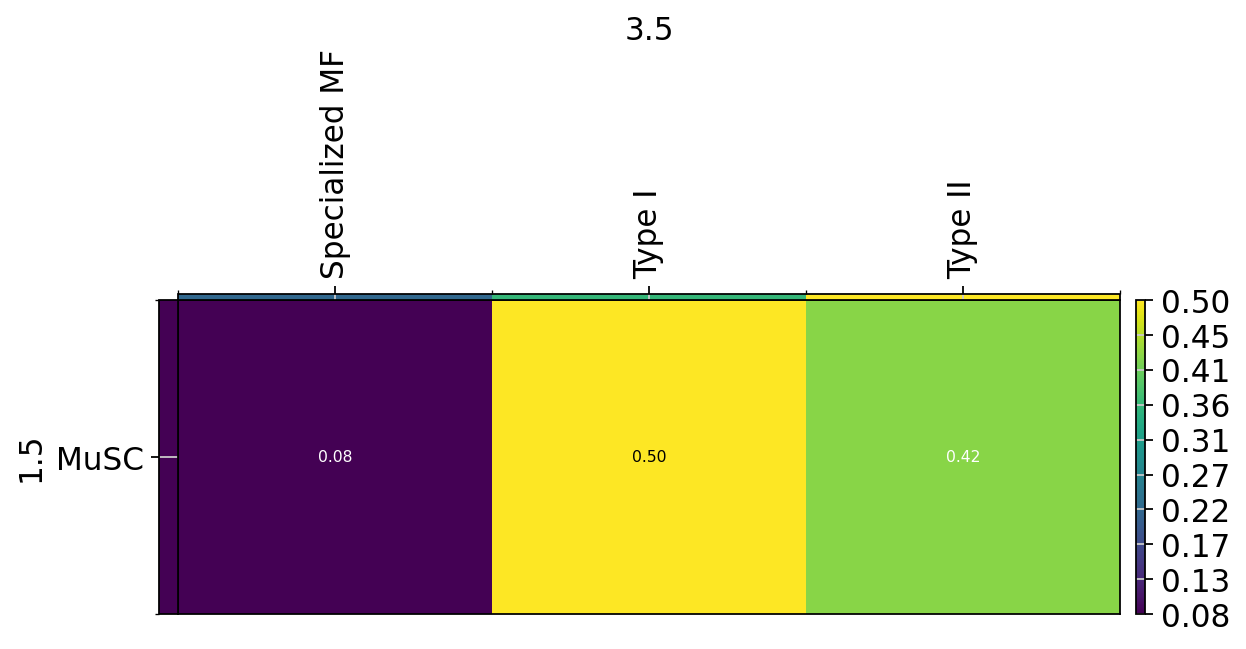

In [44]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

In [45]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

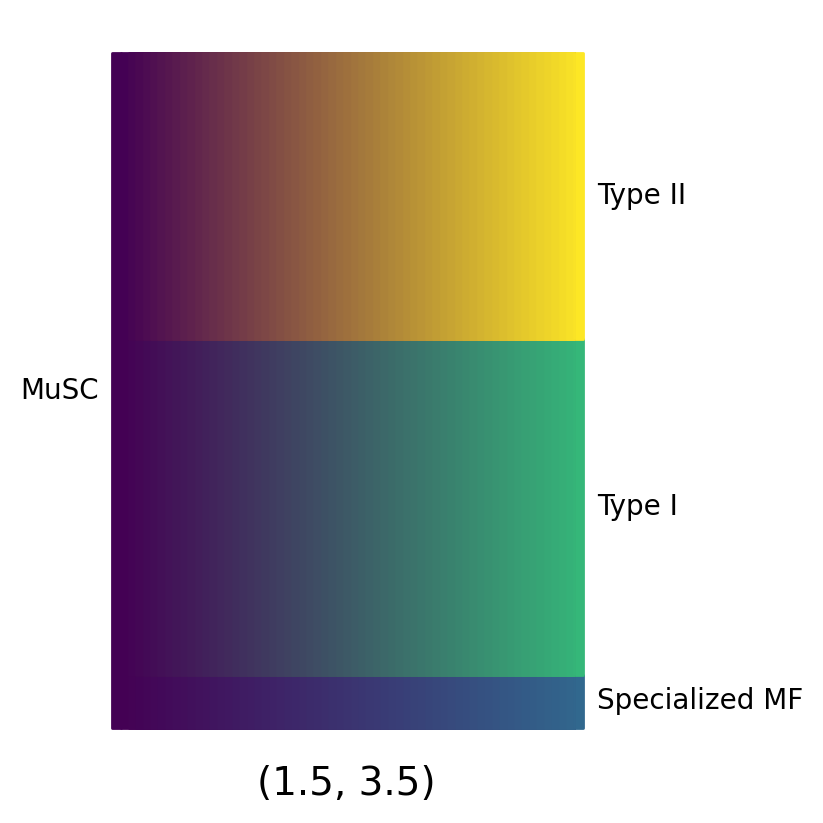

In [46]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [47]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

0.05341918 0.0 8.778708


In [48]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

normalizing counts per cell
    finished (0:00:00)


In [49]:
tp0.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_old
TCTTGGAGAC_CTGATACTTC_2_2_2,OM2_Nor4,4539.000000,2061,OM2,5.926416,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,1.5
TATCGCGCCAGGCTATATAA.1_1_2_2,OM2_Nor2,2820.000000,1543,OM2,4.219858,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,1.5
GGTGCGCGTACACTCAGTCA.1_1_1_2_2,OM2_Dam3,7118.000000,3149,OM2,4.636134,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,1.5
AGATTAAGGA_CACATGTTAC_1_2_2,OM2_Nor3,8254.000000,3133,OM2,8.250545,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,1.5
TCTTCCACAG_GTTAAGGTGA_2_2_2,OM2_Nor4,9751.000000,3543,OM2,4.707210,79.0,scRNA,Female,China,old_pop,MuSC,79_Female,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL33_N2_1_2_1_1_1_9_1,P21_5,4513.867288,1284,P21,0.016138,89.0,snRNA,Female,Spain,old_pop,Type I,89_Female,3.5
CELL1145_N1_1_2_1_1_1_9_1,P21_5,1697.597709,558,P21,0.389621,89.0,snRNA,Female,Spain,old_pop,Type II,89_Female,3.5
CELL1363_N1_1_1_2_9_1,P3_3,1851.412255,959,P3,0.743662,92.0,snRNA,Female,Spain,old_pop,Type II,92_Female,3.5
CELL621_N1_1_2_9_1,P3_5,3691.131037,1709,P3,0.054786,92.0,snRNA,Female,Spain,old_pop,Type I,92_Female,3.5


In [51]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type I',
    young_cell_cluster='MuSC',
    cell_cluster_col='Annotation',
    timepoint_col='intervals_old',
    t_young=1.5,
    t_old=3.5,
)

[pull] key='Type I_MuSC_pull' | weight sum = 2.0000
[subset] 2039 cells with Annotation=MuSC at t=1.5
count    2039.000000
mean        0.000490
std         0.000231
min         0.000087
25%         0.000302
50%         0.000496
75%         0.000657
max         0.000985
Name: Type I_MuSC_pull, dtype: float64

[result] 43 significant drivers (qval<0.05, |corr|>0.1)


,Type I_MuSC_corr,Type I_MuSC_pval,Type I_MuSC_qval,Type I_MuSC_ci_low,Type I_MuSC_ci_high,significant
ESRRG,0.241708,0.000000,0.000000,0.212450,0.270532,True
RORA,0.229905,0.000000,0.000000,0.200485,0.258911,True
TP63,0.212056,0.000000,0.000000,0.182408,0.241319,True
MEF2C,0.174162,0.000000,0.000000,0.144094,0.203908,True
PBX1,0.166655,0.000000,0.000000,0.136515,0.196486,True
ZBTB20,0.148375,0.000000,0.000000,0.118074,0.178400,True
RBFOX2,0.141589,0.000000,0.000000,0.111233,0.171681,True
NFIA,0.132358,0.000000,0.000000,0.101932,0.162536,True
NR3C2,0.128010,0.000000,0.000000,0.097554,0.158227,True
SETBP1,0.124787,0.000000,0.000000,0.094308,0.155032,True


,Type I_MuSC_corr,Type I_MuSC_pval,Type I_MuSC_qval,Type I_MuSC_ci_low,Type I_MuSC_ci_high,significant
RPS10,-0.155930,0.000000,0.000000,-0.185877,-0.125693,True
EEF1D,-0.152470,0.000000,0.000000,-0.182453,-0.122203,True
ENO1,-0.150653,0.000000,0.000000,-0.180655,-0.120371,True
RPL35,-0.145780,0.000000,0.000000,-0.175831,-0.115458,True
MYC,-0.144951,0.000000,0.000000,-0.175010,-0.114622,True
ATF4,-0.140740,0.000000,0.000000,-0.170840,-0.110377,True
RPS4X,-0.137239,0.000000,0.000000,-0.167372,-0.106850,True
RPL6,-0.137164,0.000000,0.000000,-0.167298,-0.106774,True
ID1,-0.132989,0.000000,0.000000,-0.163161,-0.102568,True
KLF6,-0.125450,0.000000,0.000000,-0.155689,-0.094976,True
